# IV. geography.csv

In [9]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
import os
import math


# Cấu hình hiển thị
pd.set_option('display.max_columns', None)
pd.set_option('display.float_format', '{:.2f}'.format)
warnings.filterwarnings('ignore')
sns.set(style="whitegrid")

# Định nghĩa đường dẫn dữ liệu (Sửa theo folder của nhóm)
CURRENT_DIR = os.getcwd()
ROOT_DIR = os.path.dirname(CURRENT_DIR)
ROOT_DIR = os.path.dirname(ROOT_DIR)
DATA_RAW_PATH = os.path.join(ROOT_DIR, "data", 'raw')
PROCESSED_PATH = os.path.join(ROOT_DIR, 'data', 'processed')
print(f"Data path: {DATA_RAW_PATH}")

IMAGES_DIR = os.path.join(ROOT_DIR, 'outputs', 'images')
if not os.path.exists(IMAGES_DIR):
    os.makedirs(IMAGES_DIR)

def load_and_clean_data():
    # 1. Load Master Data
    customers = pd.read_csv(os.path.join(DATA_RAW_PATH, 'customers.csv'))
    geography = pd.read_csv(os.path.join(DATA_RAW_PATH, 'geography.csv'))
    inventory = pd.read_csv(os.path.join(DATA_RAW_PATH, 'inventory.csv'))
    products = pd.read_csv(os.path.join(DATA_RAW_PATH, 'products.csv'))
    promotions = pd.read_csv(os.path.join(DATA_RAW_PATH, 'promotions.csv'))

    # 2. Load Transactional / Supporting Data
    orders = pd.read_csv(os.path.join(DATA_RAW_PATH, 'orders.csv'))
    order_items = pd.read_csv(os.path.join(DATA_RAW_PATH, 'order_items.csv'))
    payments = pd.read_csv(os.path.join(DATA_RAW_PATH, 'payments.csv'))
    returns = pd.read_csv(os.path.join(DATA_RAW_PATH, 'returns.csv'))
    reviews = pd.read_csv(os.path.join(DATA_RAW_PATH, 'reviews.csv'))
    sales = pd.read_csv(os.path.join(DATA_RAW_PATH, 'sales.csv'))
    sample_submission = pd.read_csv(os.path.join(DATA_RAW_PATH, 'sample_submission.csv'))
    shipments = pd.read_csv(os.path.join(DATA_RAW_PATH, 'shipments.csv'))
    web_traffic = pd.read_csv(os.path.join(DATA_RAW_PATH, 'web_traffic.csv'))

    # 3. Ép kiểu datetime cho các cột ngày tháng
    dataframes = {
        'customers': customers,
        'inventory': inventory,
        'orders': orders,
        'promotions': promotions,
        'returns': returns,
        'reviews': reviews,
        'sales': sales,
        'sample_submission': sample_submission,
        'shipments': shipments,
        'web_traffic': web_traffic,
    }

    date_cols = {
        'customers': ['signup_date'],
        'inventory': ['snapshot_date'],
        'orders': ['order_date'],
        'promotions': ['start_date', 'end_date'],
        'returns': ['return_date'],
        'reviews': ['review_date'],
        'sales': ['Date'],
        'sample_submission': ['Date'],
        'shipments': ['ship_date', 'delivery_date'],
        'web_traffic': ['date'],
    }

    for df_name, cols in date_cols.items():
        for col in cols:
            if col in dataframes[df_name].columns:
                dataframes[df_name][col] = pd.to_datetime(dataframes[df_name][col], errors='coerce')

    return (
        customers,
        geography,
        inventory,
        orders,
        order_items,
        payments,
        products,
        promotions,
        returns,
        reviews,
        sales,
        sample_submission,
        shipments,
        web_traffic,
    )

(
    customers_df,
    geography_df,
    inventory_df,
    orders_df,
    order_items_df,
    payments_df,
    products_df,
    promotions_df,
    returns_df,
    reviews_df,
    sales_df,
    sample_submission_df,
    shipments_df,
    web_traffic_df,
) = load_and_clean_data()

Data path: d:\University\Competitions\Datathon VinUni\DATATHON-2026-VinUni\data\raw


## 1. Tổng quan

In [3]:
geography_df.head(10)

,zip,city,region,district
0,15201,Hai Phong,East,District #13
1,15202,Phu Ly,East,District #13
2,15203,Viet Tri,East,District #13
3,15204,Bac Giang,East,District #13
4,15205,Bac Giang,East,District #13
5,15206,Lao Cai,East,District #13
6,15207,Hai Phong,East,District #13
7,15208,Viet Tri,East,District #13
8,15209,Ha Long,East,District #13
9,15210,Hai Phong,East,District #13


In [4]:
geography_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 39948 entries, 0 to 39947
Data columns (total 4 columns):
 #   Column    Non-Null Count  Dtype 
---  ------    --------------  ----- 
 0   zip       39948 non-null  int64 
 1   city      39948 non-null  object
 2   region    39948 non-null  object
 3   district  39948 non-null  object
dtypes: int64(1), object(3)
memory usage: 1.2+ MB


In [5]:
geography_df.columns

Index(['zip', 'city', 'region', 'district'], dtype='object')

## 1.1. Phân tích đơn biến

### 1.1.1. Biến số (Numerous)

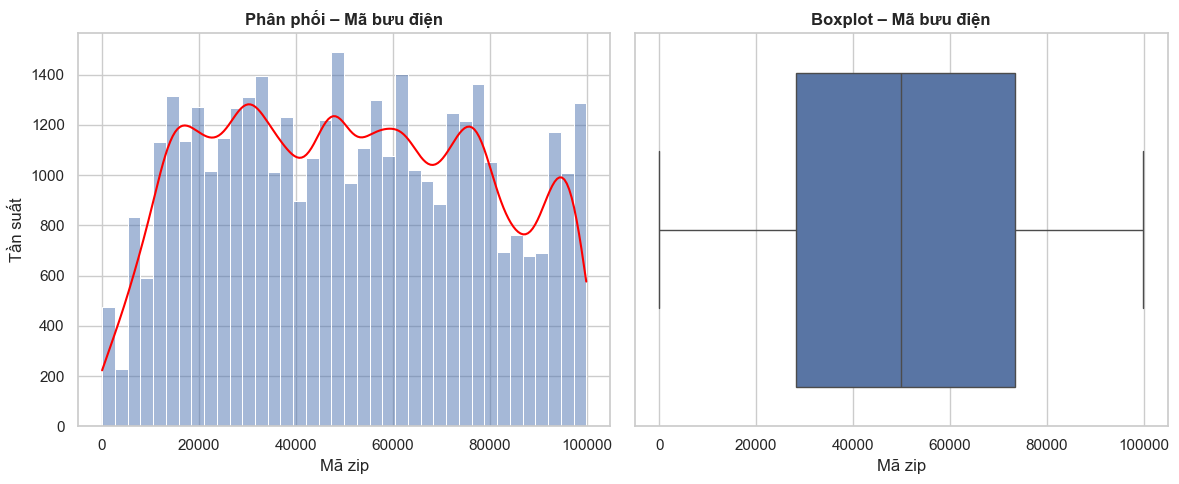

In [6]:
col_config = {
    'zip': {'title': 'Mã bưu điện', 'xlabel': 'Mã zip'}
}

# Danh sách các cột cần vẽ
con_cols_names = ['zip']

# Hàm vẽ biểu đồ phân phối (Histogram + KDE) có tính năng lưu ảnh
def plot_distribution(df, con_cols_names, save_path=None):
    n = len(con_cols_names)
    
    # Tự động tính số hàng, cột (grid)
    cols = 2  # Chỉnh thành 2 vì chúng ta chỉ có 2 cột số chính
    rows = math.ceil(n / cols)
    
    plt.figure(figsize=(6 * cols, 5 * rows))
    
    for i, col_name in enumerate(con_cols_names, 1):
        cfg = col_config.get(col_name, {'title': col_name, 'xlabel': 'Giá trị'})
        plt.subplot(rows, cols, i)
        sns.histplot(df[col_name].dropna(), kde=True)
        plt.title(f"Phân phối - {cfg['title']}", fontweight='bold')
        plt.xlabel(cfg['xlabel'])
        plt.ylabel("Tần suất")
    
    plt.tight_layout()
    
    # Lưu ảnh nếu có đường dẫn
    if save_path:
        plt.savefig(save_path, bbox_inches='tight', dpi=300)
        print(f"Đã lưu biểu đồ phân phối tại: {save_path}")
        
    plt.show()

# Hàm vẽ kết hợp Distribution và Boxplot có tính năng lưu ảnh
def plot_distribution_boxplot(df, con_cols_names, save_path=None):
    n = len(con_cols_names)
    
    plt.figure(figsize=(12, 5 * n))
    
    for i, col_name in enumerate(con_cols_names):
        cfg = col_config.get(col_name, {'title': col_name, 'xlabel': 'Giá trị'})

        # Distribution plot
        plt.subplot(n, 2, i * 2 + 1)
        ax = sns.histplot(df[col_name].dropna(), kde=True)
        ax.lines[0].set_color('red')
        plt.title(f"Phân phối – {cfg['title']}", fontweight='bold')
        plt.xlabel(cfg['xlabel'])
        plt.ylabel('Tần suất')
        
        # Box plot
        plt.subplot(n, 2, i * 2 + 2)
        sns.boxplot(x=df[col_name].dropna())
        plt.title(f"Boxplot – {cfg['title']}", fontweight='bold')
        plt.xlabel(cfg['xlabel'])
    
    plt.tight_layout()
    
    # Lưu ảnh nếu có đường dẫn
    if save_path:
        plt.savefig(save_path, bbox_inches='tight', dpi=300)
        print(f"Đã lưu biểu đồ kết hợp tại: {save_path}")
        
    plt.show()

plot_distribution_boxplot(geography_df, con_cols_names)

**Nhận xét:**

- **Quan sát:**
  - Mã bưu điện (Zip Code): Dữ liệu trải dài liên tục và phủ kín toàn bộ dải giá trị từ khoảng gần 0 đến 100.000. Biểu đồ Histogram (Phân phối) cho thấy đường cong mật độ có hình dạng đa đỉnh (multimodal), với các đỉnh tập trung rõ rệt ở quanh các mốc 30.000, 50.000, 60.000, và 75.000. Có một vùng trũng (tần suất giảm) ở dải 80.000 - 90.000.
  - Biểu đồ Boxplot cho thấy tập dữ liệu này rất cân xứng, với trung vị (median) nằm ở ngay giữa dải phân bố (khoảng 50.000). Khoảng tứ phân vị (IQR) rộng, dàn đều từ khoảng 25.000 đến 75.000. Đặc biệt, dữ liệu hoàn toàn không có điểm ngoại lai (outliers) ở cả hai đầu.

- **Insights:**
  - Về sự phân bổ địa lý: Tập khách hàng hoặc mạng lưới giao dịch được phân bổ rộng khắp các khu vực (vì mã bưu điện đại diện cho vị trí địa lý). Hình dạng đa đỉnh cho thấy doanh nghiệp không phụ thuộc vào một thị trường duy nhất mà có nhiều khu vực/tỉnh thành trọng điểm đóng góp vào mật độ giao dịch cao (tương ứng với các đỉnh trên biểu đồ).
  - Về chất lượng dữ liệu: Việc không có các giá trị ngoại lai (như số âm, số quá lớn vượt ngưỡng 100.000, hay dồn cục ở mức 0) chứng tỏ khâu thu thập và làm sạch dữ liệu đầu vào cho trường "Mã bưu điện" đang hoạt động khá tốt và chuẩn xác.
  - Lưu ý về bản chất dữ liệu: Dù hiển thị dưới dạng số (Numeric), "Mã bưu điện" thực chất là một biến định danh (Categorical variable). Giá trị 90.000 không hề mang ý nghĩa "lớn hơn" hay "quan trọng gấp 9 lần" so với giá trị 10.000. 

- **Gợi ý hành động:**
  - Khai phá đặc trưng (Feature Engineering): Khi đưa biến số này vào các mô hình học máy (đặc biệt là các mô hình tuyến tính hoặc dựa trên khoảng cách như KNN, K-Means), tuyệt đối không để nguyên dạng số học hiện tại để tránh gây nhiễu (bias) cho mô hình. Cần sử dụng các kỹ thuật như Target Encoding, One-hot Encoding (sau khi đã gom nhóm), hoặc ánh xạ (mapping) thành các biến Vĩ độ/Kinh độ (Lat/Long).
  - Phân tích và Tối ưu Logistics: Tiến hành tra cứu (lookup) các khoảng mã zip tương ứng với các đỉnh có tần suất cao (VD: 30.000, 50.000) để xác định chính xác đó là các tỉnh thành/khu vực nào. Từ đó, có cơ sở để đề xuất mở rộng hệ thống kho bãi (Hub), tối ưu hóa tuyến đường giao hàng hoặc điều phối nhân sự tập trung cho các khu vực trọng điểm này.
  - Marketing theo Vùng miền (Localize Marketing): Dựa vào các nhóm mã bưu điện có mật độ dày đặc, đội ngũ Marketing có thể thiết kế các chiến dịch quảng cáo nhắm mục tiêu theo khu vực địa lý (Geotargeting) thay vì chạy dàn trải trên toàn quốc, giúp tiết kiệm ngân sách và tăng tỷ lệ chuyển đổi.

### 1.1.2. Biến phân loại (Categorical)

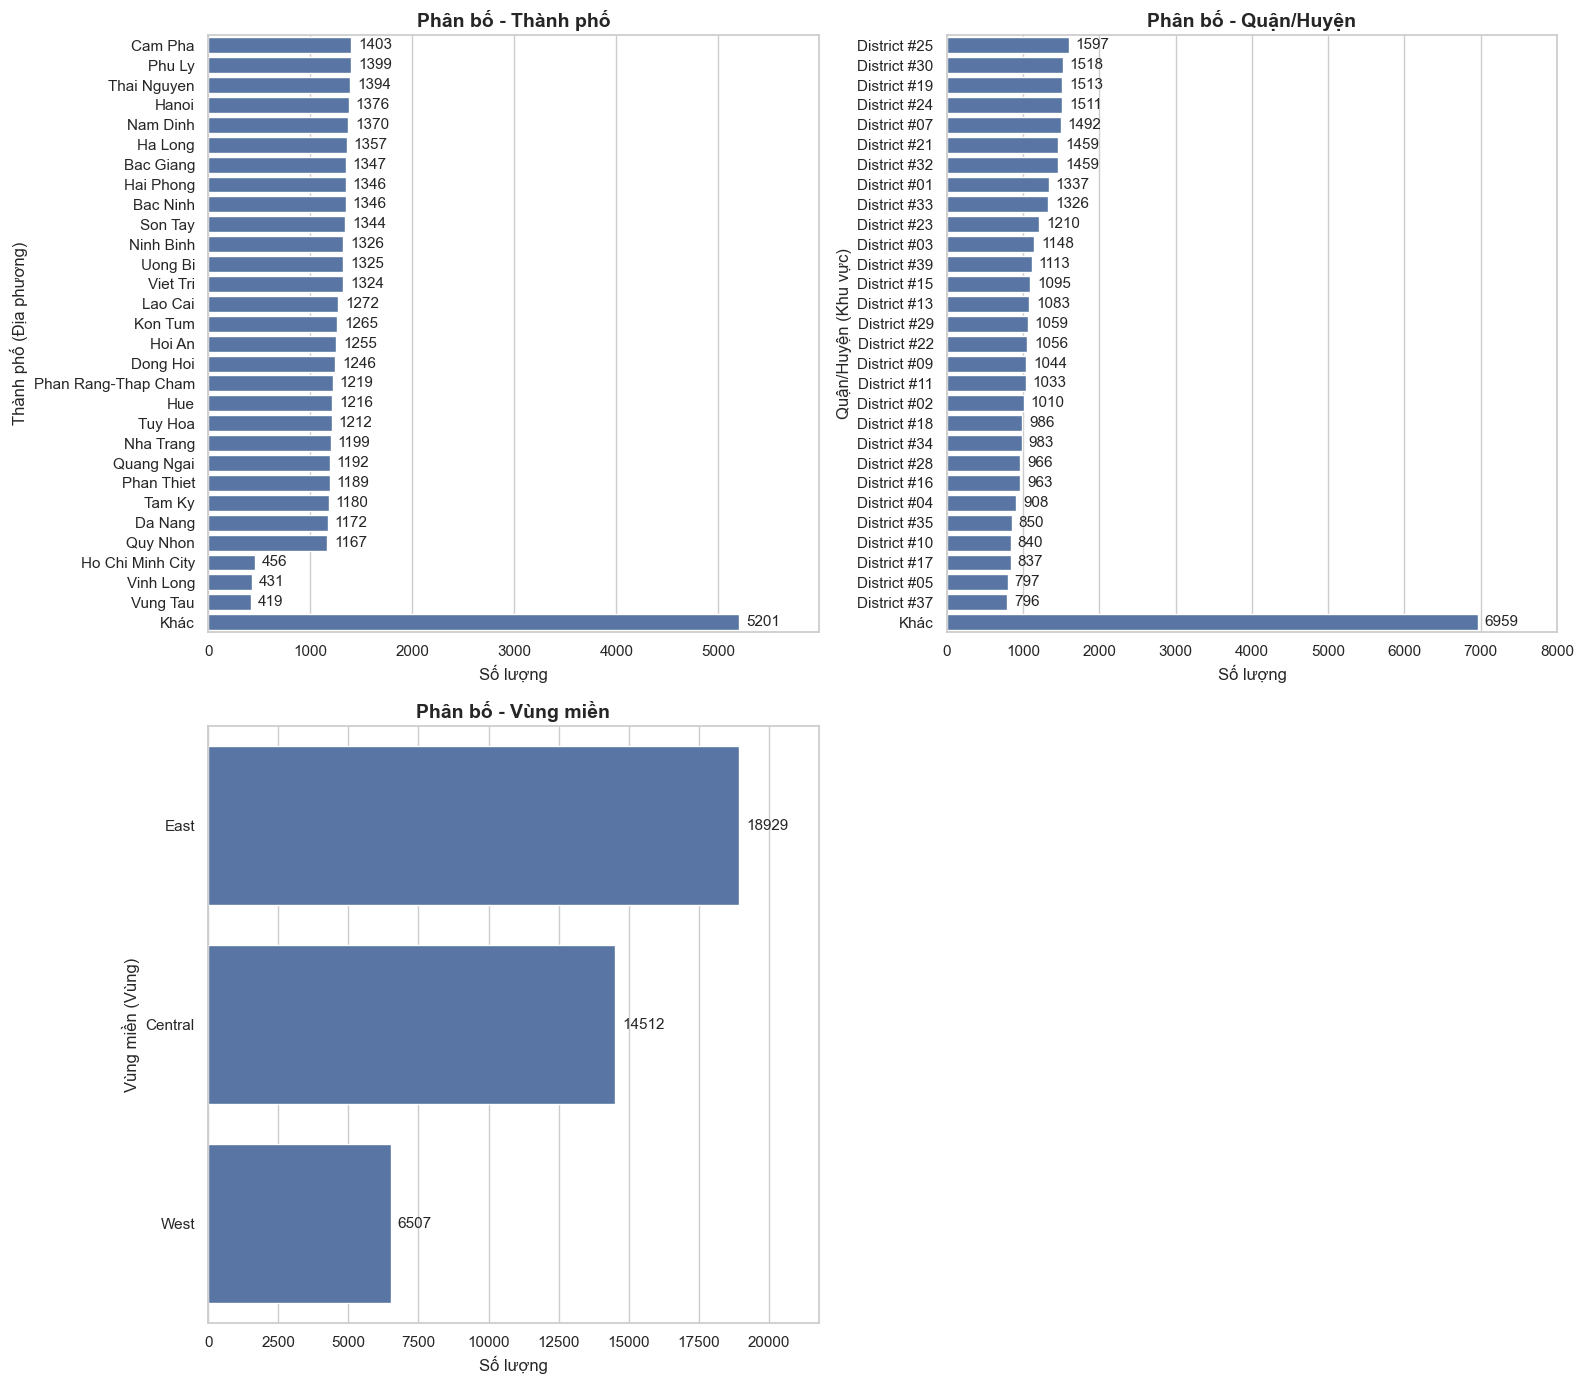

In [19]:
COL_INFO = {
    'city': {'name': 'Thành phố', 'unit': 'Địa phương'},
    'region': {'name': 'Vùng miền', 'unit': 'Vùng'},
    'district': {'name': 'Quận/Huyện', 'unit': 'Khu vực'}
}

# 2. Hàm vẽ biểu đồ phân bố Categorical (Bar chart ngang)
def plot_horizontal_bar_chart(df, cate_cols_names):
    n = len(cate_cols_names)
    cols = 2
    rows = math.ceil(n / cols)

    # Thiết lập kích thước: Tăng chiều ngang để có không gian cho số liệu
    fig, axes = plt.subplots(rows, cols, figsize=(16, 7 * rows)) 
    axes = axes.flatten()

    for i, col_name in enumerate(cate_cols_names):
        ax = axes[i]
        
        if col_name in df.columns:
            # Lấy tần suất xuất hiện, điền 'Không xác định' cho các giá trị bị thiếu (NaN)
            val_counts = df[col_name].fillna('Không xác định').value_counts()
            
            # Xử lý: Lấy top 9, nhóm phần còn lại thành 'Khác'
            TOP = 30
            if len(val_counts) > TOP:
                top9 = val_counts.iloc[:(TOP - 1)]
                other_sum = val_counts.iloc[(TOP - 1):].sum()
                plot_data = pd.concat([top9, pd.Series({'Khác': other_sum})])
            else:
                plot_data = val_counts
                
            # Đảm bảo index là kiểu chuỗi
            plot_data.index = plot_data.index.astype(str)
            
            # Vẽ Bar chart ngang (Thêm palette viridis cho sinh động)
            sns.barplot(x=plot_data.values, y=plot_data.index, ax=ax)
            
            # Lấy thông tin Tên và Đơn vị từ Từ điển
            info = COL_INFO.get(col_name, {'name': col_name, 'unit': 'Loại'}) 
            
            # Cài đặt tiêu đề và nhãn
            ax.set_title(f"Phân bố - {info['name']}", fontsize=14, fontweight='bold')
            ax.set_xlabel("Số lượng", fontsize=12)
            ax.set_ylabel(f"{info['name']} ({info['unit']})", fontsize=12)
            
            # Thêm con số thực tế bên phải mỗi thanh bar
            for p in ax.patches:
                width = p.get_width()
                if width > 0:
                    ax.annotate(f'{int(width)}', 
                                (width, p.get_y() + p.get_height() / 2.), 
                                ha='left', va='center', fontsize=11, 
                                xytext=(5, 0), textcoords='offset points')
            
            # Mở rộng giới hạn trục x thêm 15% để số liệu (annotate) không bị che khuất
            ax.set_xlim(0, max(plot_data.values) * 1.15)
            
        else:
            ax.set_visible(False)
            
    # Ẩn các trục không sử dụng nếu số lượng cột là số lẻ
    for j in range(i + 1, len(axes)):
        axes[j].set_visible(False)

    plt.tight_layout()
    plt.show()

# 3. Chạy hàm với các cột cần vẽ
cate_cols = ['city', 'district', 'region']
plot_horizontal_bar_chart(geography_df, cate_cols)

#### a. Cột thành phố

In [16]:
geography_df['city'].unique()

array(['Hai Phong', 'Phu Ly', 'Viet Tri', 'Bac Giang', 'Lao Cai',
       'Ha Long', 'Cam Pha', 'Son Tay', 'Ninh Binh', 'Bac Ninh',
       'Nam Dinh', 'Hanoi', 'Uong Bi', 'Thai Nguyen', 'Kon Tum', 'Hoi An',
       'Phan Rang-Thap Cham', 'Dong Hoi', 'Quang Ngai', 'Tuy Hoa', 'Hue',
       'Da Nang', 'Phan Thiet', 'Quy Nhon', 'Nha Trang', 'Tam Ky',
       'Vung Tau', 'Bien Hoa', 'Vinh Long', 'Buon Ma Thuot', 'Tra Vinh',
       'My Tho', 'Bac Lieu', 'Rach Gia', 'Long Xuyen', 'Soc Trang',
       'Pleiku', 'Can Tho', 'Ca Mau', 'Da Lat', 'Ben Tre',
       'Ho Chi Minh City'], dtype=object)

In [13]:
geography_df['city'].value_counts()

city
Cam Pha                1403
Phu Ly                 1399
Thai Nguyen            1394
Hanoi                  1376
Nam Dinh               1370
Ha Long                1357
Bac Giang              1347
Hai Phong              1346
Bac Ninh               1346
Son Tay                1344
Ninh Binh              1326
Uong Bi                1325
Viet Tri               1324
Lao Cai                1272
Kon Tum                1265
Hoi An                 1255
Dong Hoi               1246
Phan Rang-Thap Cham    1219
Hue                    1216
Tuy Hoa                1212
Nha Trang              1199
Quang Ngai             1192
Phan Thiet             1189
Tam Ky                 1180
Da Nang                1172
Quy Nhon               1167
Ho Chi Minh City        456
Vinh Long               431
Vung Tau                419
Ca Mau                  416
Pleiku                  414
Long Xuyen              408
My Tho                  408
Da Lat                  408
Buon Ma Thuot           401
Bien Hoa       

#### b. Cột district

In [15]:
geography_df['district'].unique()

array(['District #13', 'District #04', 'District #06', 'District #05',
       'District #03', 'District #01', 'District #14', 'District #15',
       'District #02', 'District #10', 'District #12', 'District #09',
       'District #16', 'District #18', 'District #17', 'District #08',
       'District #11', 'District #07', 'District #19', 'District #25',
       'District #30', 'District #32', 'District #21', 'District #24',
       'District #28', 'District #20', 'District #29', 'District #27',
       'District #22', 'District #31', 'District #26', 'District #23',
       'District #36', 'District #35', 'District #38', 'District #39',
       'District #37', 'District #34', 'District #33'], dtype=object)

In [14]:
geography_df['district'].value_counts()

district
District #25    1597
District #30    1518
District #19    1513
District #24    1511
District #07    1492
District #21    1459
District #32    1459
District #01    1337
District #33    1326
District #23    1210
District #03    1148
District #39    1113
District #15    1095
District #13    1083
District #29    1059
District #22    1056
District #09    1044
District #11    1033
District #02    1010
District #18     986
District #34     983
District #28     966
District #16     963
District #04     908
District #35     850
District #10     840
District #17     837
District #05     797
District #37     796
District #36     779
District #27     771
District #08     765
District #06     749
District #20     725
District #12     691
District #38     660
District #26     644
District #14     638
District #31     537
Name: count, dtype: int64

**Nhận xét:**

- **Quan sát:**
    - Biến Thành phố (Địa phương): Phân phối dữ liệu khá đồng đều ở các thành phố top đầu (Cam Phả, Phủ Lý, Thái Nguyên, Hà Nội...) với số lượng dao động từ 1.300 - 1.400 quan sát. Điểm nổi bật nhất là nhóm "Khác" chiếm tỷ trọng áp đảo (5.201). Đáng chú ý, các trung tâm lớn như TP.HCM hay Vũng Tàu lại nằm ở nhóm cuối với tần suất rất thấp (dưới 500).
    - Biến Quận/Huyện (Khu vực): Các đơn vị đã được ẩn danh dưới dạng "District #X". Tương tự như biến Thành phố, mức độ phân tán cao với phần lớn quan sát rơi vào nhóm "Khác" (6.959). Trong các quận/huyện được định danh, District #25 và #30 dẫn đầu với hơn 1.500 quan sát, sau đó giảm dần đều theo dạng bậc thang.
    - Biến Vùng miền (Vùng): Có sự phân hóa rõ rệt thành 3 tập. Khu vực "East" (Đông) chiếm ưu thế tuyệt đối với mức cao nhất (18.929), gấp gần 3 lần so với khu vực "West" (Tây - 6.507). Vùng "Central" (Trung) nằm ở mức giữa với 14.512 quan sát.

- **Insights:**
    - Sự thiên lệch dữ liệu không gian (Spatial Data Imbalance): Mẫu dữ liệu này không phản ánh phân bố dân cư/kinh tế tiêu chuẩn (nơi các thành phố cực lớn như TP.HCM thường chiếm đa số). Tập dữ liệu đang tập trung cực kỳ mạnh vào khu vực phía Đông ("East") và các tỉnh, thành phố tuyến 2 (Tier-2 cities) hoặc khu vực công nghiệp/khai thác (như Cam Phả). 
    - Đặc trưng dữ liệu Categorical có tính Cardinality cao: Biến Quận/Huyện và Thành phố có quá nhiều nhãn (high cardinality). Việc hệ thống gom một lượng dữ liệu khổng lồ vào nhãn "Khác" ở cả hai cấp độ đang che khuất các cụm (clusters) không gian tiềm năng, làm mất đi tính hạt nhân (granularity) thiết yếu cho việc phân tích độ sâu.
    - Dấu hiệu của xử lý dữ liệu đầu vào: Việc Quận/Huyện được đặt tên theo mã (District #25, #30) cho thấy dữ liệu có thể đã qua một bước masking bảo mật, hoặc đang được phân chia theo một hệ thống lưới không gian (spatial grid/zones) riêng của doanh nghiệp chứ không theo đơn vị hành chính thông thường.

- **Gợi ý hành động:**
    - Xử lý lại biến "Khác" (Others): Để tối ưu hóa cho các mô hình học máy (Machine Learning) về không gian, cần rà soát lại quy trình gom nhóm (grouping). Nên hạ ngưỡng (threshold) gom nhóm xuống thấp hơn (ví dụ: chỉ gộp vào "Khác" các khu vực có dưới 100 quan sát) để bóc tách thêm các đặc trưng địa phương quan trọng, tránh hiện tượng mô hình bị nhiễu (noise) hoặc underfitting tại nhóm "Khác".
    - Áp dụng kỹ thuật Encoding phù hợp: Thay vì One-Hot Encoding dễ gây bùng nổ số lượng chiều dữ liệu (Curse of Dimensionality) với các biến địa lý này, hãy ưu tiên các phương pháp như Target Encoding (mã hóa theo biến mục tiêu) hoặc Frequency/Count Encoding để bảo toàn thông tin về sự phân bố khu vực.
    - Lấy mẫu phân tầng (Stratified Sampling): Khi chia tập train/test cho các tác vụ dự báo (ví dụ: dự đoán giá trị hoặc phân loại), bắt buộc phải áp dụng lấy mẫu phân tầng dựa trên biến "Vùng miền" hoặc gán trọng số lớp (Class Weights). Điều này giúp mô hình không bị bias (thiên lệch) hoàn toàn vào vùng "East" mà bỏ qua các đặc trưng của vùng "West".

## 1.2. Phân tích 2 biến

### 1.2.1. Phân tích tương quan

### 1.2.2. Phân tích cross table